# XGBoost - Option Price Prediction

The project aims to develop a machine learning model to predict option prices by combining traditional financial models with sentiment analysis of news articles.

References:
- https://www.sciencedirect.com/science/article/pii/S0304405X24001235
- https://thesis.eur.nl/pub/67130/Thesis_MvLent_Final.pdf

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    explained_variance_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [2]:
# Options: secid, date, exdate, cp_flag, strike_price, best_bid, best_offer,
#          volume, impl_volatility, delta, gamma, vega, theta, optionid,
#          forward_price, ticker, index_flag, issuer, exercise_style
options_df = pd.read_csv('options.csv', low_memory=False)

# Stock: PERMNO, HdrCUSIP, Ticker, PERMCO, DlyCalDt, DlyPrc, DlyVol,
#        DlyClose, DlyLow, DlyHigh, DlyBid, DlyAsk, DlyOpen, DlyNumTrd
stock_df = pd.read_csv('stocks.csv', low_memory=False)

print('Options shape:', options_df.shape, '\nColumns:', list(options_df.columns))
print('\nStock shape:', stock_df.shape, '\nColumns:', list(stock_df.columns))

Options shape: (3373875, 19) 
Columns: ['secid', 'date', 'exdate', 'cp_flag', 'strike_price', 'best_bid', 'best_offer', 'volume', 'impl_volatility', 'delta', 'gamma', 'vega', 'theta', 'optionid', 'forward_price', 'ticker', 'index_flag', 'issuer', 'exercise_style']

Stock shape: (1008, 14) 
Columns: ['PERMNO', 'HdrCUSIP', 'Ticker', 'PERMCO', 'DlyCalDt', 'DlyPrc', 'DlyVol', 'DlyClose', 'DlyLow', 'DlyHigh', 'DlyBid', 'DlyAsk', 'DlyOpen', 'DlyNumTrd']


In [3]:
print(options_df.head())
print(stock_df.head())

    secid        date      exdate cp_flag  strike_price  best_bid  best_offer  \
0  101062  2024-08-29  2024-08-30       C        300000     266.9      272.25   
1  101062  2024-08-29  2024-08-30       C        310000     256.9      262.25   
2  101062  2024-08-29  2024-08-30       C        320000     246.9      252.25   
3  101062  2024-08-29  2024-08-30       C        330000     236.9      242.25   
4  101062  2024-08-29  2024-08-30       C        340000     226.9      232.25   

   volume  impl_volatility  delta  gamma  vega  theta   optionid  \
0       0              NaN    NaN    NaN   NaN    NaN  162978660   
1       0              NaN    NaN    NaN   NaN    NaN  162978661   
2       0              NaN    NaN    NaN   NaN    NaN  162978662   
3       0              NaN    NaN    NaN   NaN    NaN  162978663   
4       0              NaN    NaN    NaN   NaN    NaN  162978664   

   forward_price ticker  index_flag     issuer exercise_style  
0            NaN   ADBE           0  ADO

In [4]:
print('\nOptions dtypes:\n', options_df.dtypes)
print('\nStock dtypes:\n', stock_df.dtypes)


Options dtypes:
 secid                int64
date                object
exdate              object
cp_flag             object
strike_price         int64
best_bid           float64
best_offer         float64
volume               int64
impl_volatility    float64
delta              float64
gamma              float64
vega               float64
theta              float64
optionid             int64
forward_price      float64
ticker              object
index_flag           int64
issuer              object
exercise_style      object
dtype: object

Stock dtypes:
 PERMNO         int64
HdrCUSIP      object
Ticker        object
PERMCO         int64
DlyCalDt      object
DlyPrc       float64
DlyVol         int64
DlyClose     float64
DlyLow       float64
DlyHigh      float64
DlyBid       float64
DlyAsk       float64
DlyOpen      float64
DlyNumTrd      int64
dtype: object


## 3. Preprocessing & Merge

In [5]:
# Standardise ticker & date for merge
options_df['ticker'] = options_df['ticker'].astype(str).str.strip().str.upper()
stock_df['Ticker']   = stock_df['Ticker'].astype(str).str.strip().str.upper()

options_df['date']   = pd.to_datetime(options_df['date'])
options_df['exdate'] = pd.to_datetime(options_df['exdate'])
stock_df['DlyCalDt'] = pd.to_datetime(stock_df['DlyCalDt'])

# Rename stock columns for merge
stock_df.rename(columns={'Ticker': 'ticker', 'DlyCalDt': 'date'}, inplace=True)

# Target: option mid-price
options_df['option_price'] = (options_df['best_bid'] + options_df['best_offer']) / 2

In [6]:
print('\nMissing values in options data:\n', options_df.isnull().sum())
print('\nMissing values in stock data:\n', stock_df.isnull().sum())


Missing values in options data:
 secid                    0
date                     0
exdate                   0
cp_flag                  0
strike_price             0
best_bid                 0
best_offer               0
volume                   0
impl_volatility     267024
delta               267024
gamma               267024
vega                267024
theta               267024
optionid                 0
forward_price      3373875
ticker                   0
index_flag               0
issuer                   0
exercise_style           0
option_price             0
dtype: int64

Missing values in stock data:
 PERMNO       0
HdrCUSIP     0
ticker       0
PERMCO       0
date         0
DlyPrc       0
DlyVol       0
DlyClose     0
DlyLow       0
DlyHigh      0
DlyBid       0
DlyAsk       0
DlyOpen      0
DlyNumTrd    0
dtype: int64


In [7]:
# Merge on ticker + date
merged_df = pd.merge(options_df, stock_df, on=['ticker', 'date'], how='inner')
print(f'\nMerged Data Shape: {merged_df.shape}')
print(merged_df.head())


Merged Data Shape: (3373875, 32)
    secid       date     exdate cp_flag  strike_price  best_bid  best_offer  \
0  101062 2024-08-29 2024-08-30       C        300000     266.9      272.25   
1  101062 2024-08-29 2024-08-30       C        310000     256.9      262.25   
2  101062 2024-08-29 2024-08-30       C        320000     246.9      252.25   
3  101062 2024-08-29 2024-08-30       C        330000     236.9      242.25   
4  101062 2024-08-29 2024-08-30       C        340000     226.9      232.25   

   volume  impl_volatility  delta  ...  PERMCO  DlyPrc   DlyVol  DlyClose  \
0       0              NaN    NaN  ...    8476  569.63  1946261    569.63   
1       0              NaN    NaN  ...    8476  569.63  1946261    569.63   
2       0              NaN    NaN  ...    8476  569.63  1946261    569.63   
3       0              NaN    NaN  ...    8476  569.63  1946261    569.63   
4       0              NaN    NaN  ...    8476  569.63  1946261    569.63   

   DlyLow DlyHigh  DlyBid  D

In [8]:
# Drop forward_price (mostly NaN) and clean
if 'forward_price' in merged_df.columns:
    merged_df.drop(columns=['forward_price'], inplace=True)

merged_df.dropna(subset=['impl_volatility', 'delta', 'gamma', 'vega', 'theta',
                         'option_price', 'DlyPrc', 'DlyClose', 'DlyVol'], inplace=True)
merged_df.sort_values(by=['ticker', 'date'], inplace=True)
merged_df.reset_index(drop=True, inplace=True)
print(f'\nAfter clean: {merged_df.shape}')


After clean: (3106851, 31)


In [9]:
print('\nSummary statistics:\n', merged_df.describe())


Summary statistics:
               secid                           date  \
count  3.106851e+06                        3106851   
mean   1.098121e+05  2025-02-28 23:31:08.885892608   
min    1.010620e+05            2024-08-29 00:00:00   
25%    1.083210e+05            2024-11-22 00:00:00   
50%    1.083210e+05            2025-03-03 00:00:00   
75%    1.154220e+05            2025-06-05 00:00:00   
max    1.154220e+05            2025-08-29 00:00:00   
std    5.336222e+03                            NaN   

                              exdate  strike_price      best_bid  \
count                        3106851  3.106851e+06  3.106851e+06   
mean   2025-10-18 08:27:59.888994304  5.063124e+05  1.038947e+02   
min              2024-08-30 00:00:00  5.000000e+02  0.000000e+00   
25%              2025-03-21 00:00:00  1.290000e+05  1.490000e+00   
50%              2025-08-15 00:00:00  3.650000e+05  2.675000e+01   
75%              2026-01-16 00:00:00  7.400000e+05  1.041500e+02   
max            

## 4. Feature Engineering (incl. Skewness)

In [10]:
# Days to expiration
merged_df['days_to_expiry'] = (merged_df['exdate'] - merged_df['date']).dt.days

# Moneyness (strike_price in OptionMetrics is x1000)
merged_df['strike_price_adj'] = merged_df['strike_price'] / 1000.0
merged_df['moneyness'] = merged_df['DlyClose'] / merged_df['strike_price_adj']

# Stock daily return
merged_df['daily_return'] = merged_df.groupby('ticker')['DlyClose'].pct_change()

# Spreads and ranges
merged_df['daily_spread'] = merged_df['DlyAsk'] - merged_df['DlyBid']
merged_df['daily_range']  = merged_df['DlyHigh'] - merged_df['DlyLow']
merged_df['option_spread'] = merged_df['best_offer'] - merged_df['best_bid']

In [11]:
# === SKEWNESS CALCULATIONS (rolling 20-day window) ===

# Rolling skewness of stock returns per ticker
merged_df['return_skewness'] = (
    merged_df.groupby('ticker')['daily_return']
    .transform(lambda x: x.rolling(window=20, min_periods=5).skew())
)

# Rolling skewness of implied volatility per ticker
merged_df['iv_skewness'] = (
    merged_df.groupby('ticker')['impl_volatility']
    .transform(lambda x: x.rolling(window=20, min_periods=5).skew())
)

# Rolling skewness of option volume per ticker
merged_df['volume_skewness'] = (
    merged_df.groupby('ticker')['volume']
    .transform(lambda x: x.rolling(window=20, min_periods=5).skew())
)

# Cross-sectional skewness of option prices by date
merged_df['price_skewness_cross'] = (
    merged_df.groupby('date')['option_price']
    .transform(lambda x: x.skew())
)

print('Skewness features computed.')
print(merged_df[['return_skewness', 'iv_skewness', 'volume_skewness', 'price_skewness_cross']].describe())

Skewness features computed.
       return_skewness   iv_skewness  volume_skewness  price_skewness_cross
count     3.106836e+06  3.106839e+06     3.106839e+06          3.106851e+06
mean      1.525817e-03  1.450761e+00     2.484749e+00          2.621503e+00
std       3.105321e-01  1.434763e+00     4.295382e+00          2.263045e-01
min      -4.472136e+00 -4.454703e+00    -1.210615e+02          2.027807e+00
25%       0.000000e+00  2.660567e-01     1.772881e+00          2.436729e+00
50%       0.000000e+00  1.067628e+00     2.836037e+00          2.666344e+00
75%       0.000000e+00  2.834191e+00     3.989004e+00          2.783728e+00
max       4.472136e+00  4.472135e+00     7.770008e+01          3.095847e+00


In [12]:
# Drop rows with NaN from rolling calculations
merged_df.dropna(subset=['return_skewness', 'iv_skewness', 'volume_skewness',
                         'price_skewness_cross', 'daily_return'], inplace=True)
merged_df.reset_index(drop=True, inplace=True)
print(f'After feature engineering: {merged_df.shape}')

After feature engineering: (3106836, 42)


In [13]:
# Save merged data
merged_df.to_csv('merged_data.csv', index=False)
print('Merged dataset saved as merged_data.csv')

Merged dataset saved as merged_data.csv


## 5. Train / Test Split & Scaling

In [14]:
df = merged_df.copy()

# Encode cp_flag as numeric
df['cp_flag_encoded'] = LabelEncoder().fit_transform(df['cp_flag'].astype(str))

# Define numerical features
num_features = [
    'delta', 'gamma', 'vega', 'theta',
    'strike_price_adj', 'impl_volatility',
    'DlyPrc', 'DlyClose', 'DlyVol', 'DlyLow', 'DlyHigh',
    'DlyBid', 'DlyAsk', 'DlyOpen', 'DlyNumTrd',
    'volume',
    'days_to_expiry', 'moneyness', 'daily_return',
    'daily_spread', 'daily_range', 'option_spread',
    'return_skewness', 'iv_skewness', 'volume_skewness', 'price_skewness_cross',
    'cp_flag_encoded'
]
num_features = [f for f in num_features if f in df.columns]
target = 'option_price'

print(f'Using {len(num_features)} features: {num_features}')

Using 27 features: ['delta', 'gamma', 'vega', 'theta', 'strike_price_adj', 'impl_volatility', 'DlyPrc', 'DlyClose', 'DlyVol', 'DlyLow', 'DlyHigh', 'DlyBid', 'DlyAsk', 'DlyOpen', 'DlyNumTrd', 'volume', 'days_to_expiry', 'moneyness', 'daily_return', 'daily_spread', 'daily_range', 'option_spread', 'return_skewness', 'iv_skewness', 'volume_skewness', 'price_skewness_cross', 'cp_flag_encoded']


In [15]:
# Replace inf with NaN, then drop
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=num_features + [target], inplace=True)

X = df[num_features]
y = df[target]
print(f'Final X shape: {X.shape}, y shape: {y.shape}')

Final X shape: (3106836, 27), y shape: (3106836,)


In [16]:
# Temporal split (80/20) - preserves time ordering
split_index = int(0.8 * len(df))
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f'Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')

Train size: 2485468, Test size: 621368


In [18]:
# Scale features
scaler = StandardScaler()
X_tr = scaler.fit_transform(X_train)
X_te = scaler.transform(X_test)

## 6. Train XGBoost Model (without Sentiment)

In [19]:
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
xgb_model.fit(X_tr, y_train)
print('XGBoost model trained.')

XGBoost model trained.


In [20]:
# Predictions
y_pred_tr = xgb_model.predict(X_tr)
y_pred_te = xgb_model.predict(X_te)

## 7. Evaluation

In [21]:
# === Regression Metrics ===
def compute_metrics(yt, yp, label):
    mse = mean_squared_error(yt, yp)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(yt, yp)
    r2 = r2_score(yt, yp)
    evs = explained_variance_score(yt, yp)
    m = yt != 0
    mape = np.mean(np.abs((yt[m] - yp[m]) / yt[m])) * 100 if m.sum() > 0 else np.nan
    print(f'\n{"="*50}')
    print(f'  {label}')
    print(f'{"="*50}')
    print(f'  MSE:                    {mse:.4f}')
    print(f'  RMSE:                   {rmse:.4f}')
    print(f'  MAE:                    {mae:.4f}')
    print(f'  MAPE:                   {mape:.2f}%')
    print(f'  R-squared:              {r2:.4f}')
    print(f'  Explained Variance:     {evs:.4f}')
    return dict(MSE=mse, RMSE=rmse, MAE=mae, MAPE=mape, R2=r2, EVS=evs)

tr_m = compute_metrics(y_train.values, y_pred_tr, 'XGBOOST - TRAIN SET')
te_m = compute_metrics(y_test.values, y_pred_te, 'XGBOOST - TEST SET')


  XGBOOST - TRAIN SET
  MSE:                    189.8755
  RMSE:                   13.7795
  MAE:                    7.3321
  MAPE:                   272.42%
  R-squared:              0.9958
  Explained Variance:     0.9958

  XGBOOST - TEST SET
  MSE:                    84.8580
  RMSE:                   9.2118
  MAE:                    4.3086
  MAPE:                   699.74%
  R-squared:              0.9499
  Explained Variance:     0.9508


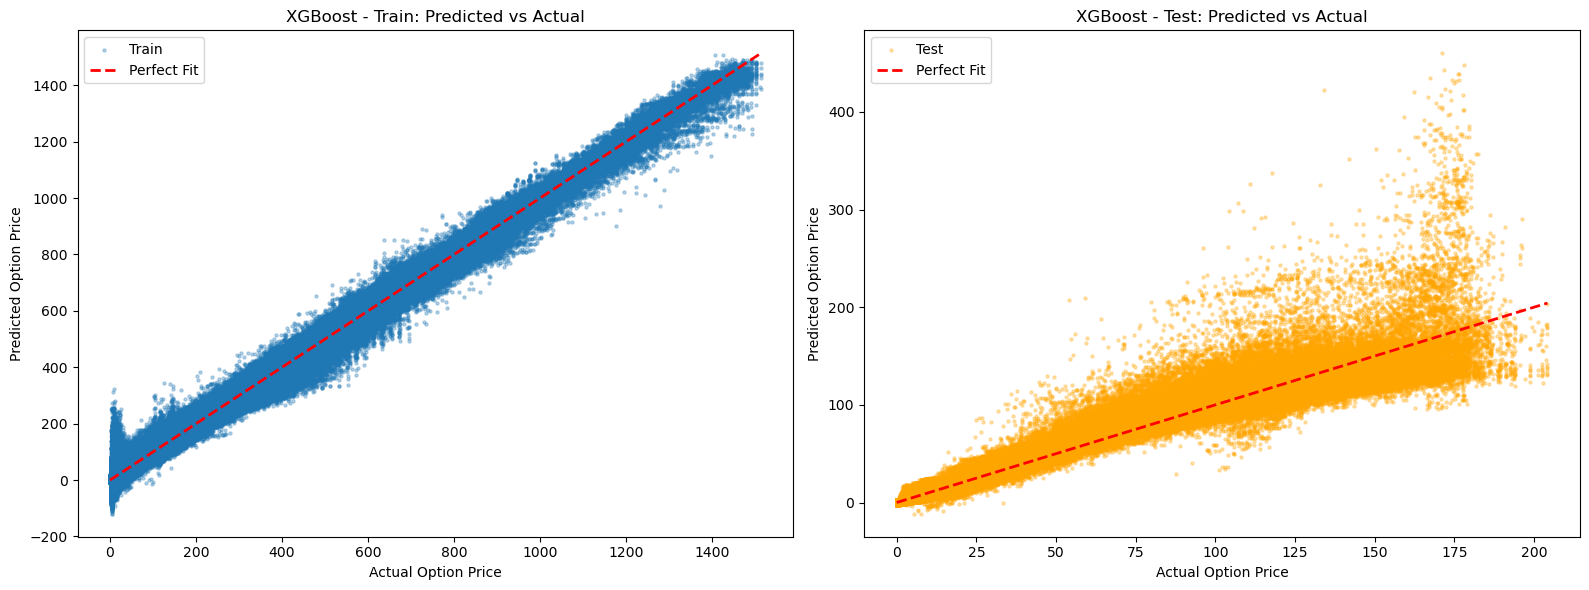

In [22]:
# === 1. Predicted vs Actual Scatter Plot ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_train, y_pred_tr, alpha=0.3, s=5, label='Train')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Option Price')
axes[0].set_ylabel('Predicted Option Price')
axes[0].set_title('XGBoost - Train: Predicted vs Actual')
axes[0].legend()

axes[1].scatter(y_test, y_pred_te, alpha=0.3, s=5, color='orange', label='Test')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
axes[1].set_xlabel('Actual Option Price')
axes[1].set_ylabel('Predicted Option Price')
axes[1].set_title('XGBoost - Test: Predicted vs Actual')
axes[1].legend()

plt.tight_layout()
plt.show()

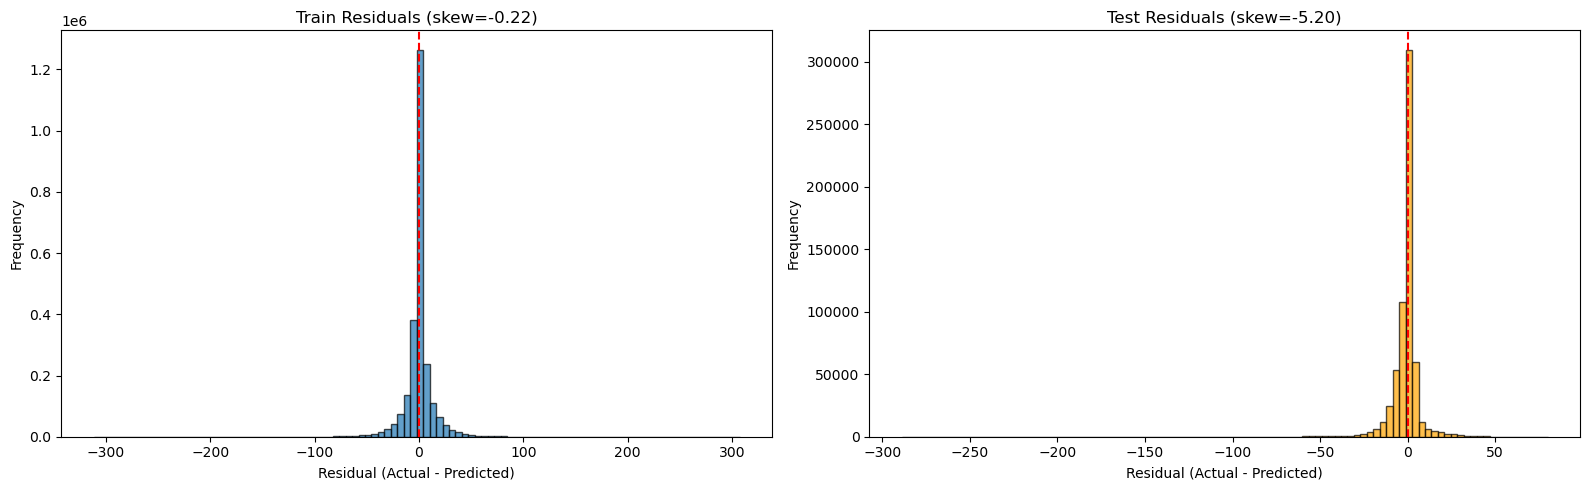

In [23]:
# === 2. Residual Distribution ===
res_tr = y_train.values - y_pred_tr
res_te = y_test.values - y_pred_te

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(res_tr, bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='r', linestyle='--')
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Train Residuals (skew={stats.skew(res_tr):.2f})')

axes[1].hist(res_te, bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Test Residuals (skew={stats.skew(res_te):.2f})')

plt.tight_layout()
plt.show()

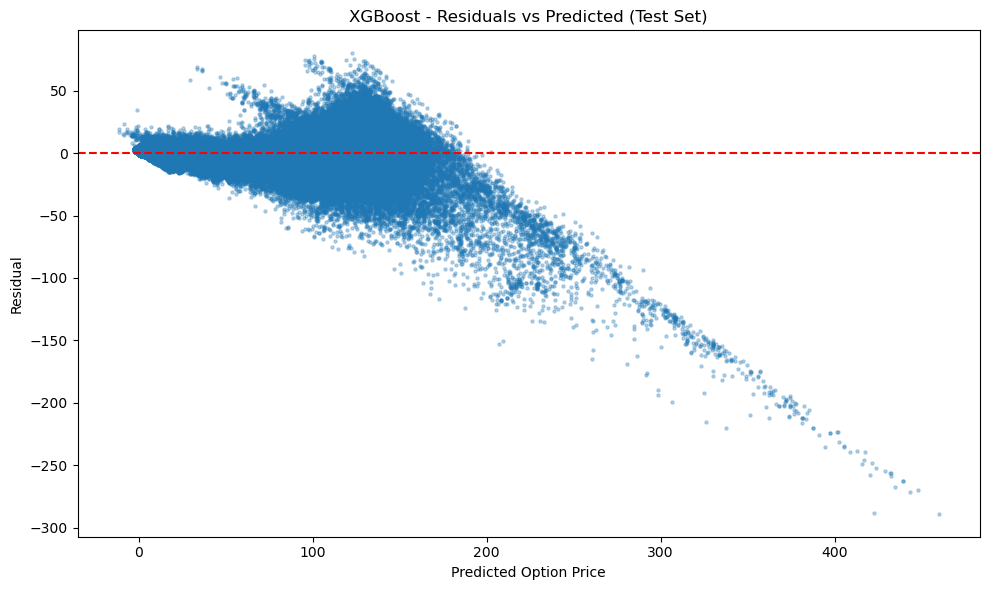

In [24]:
# === 3. Residuals vs Predicted (heteroscedasticity check) ===
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_te, res_te, alpha=0.3, s=5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Option Price')
plt.ylabel('Residual')
plt.title('XGBoost - Residuals vs Predicted (Test Set)')
plt.tight_layout()
plt.show()

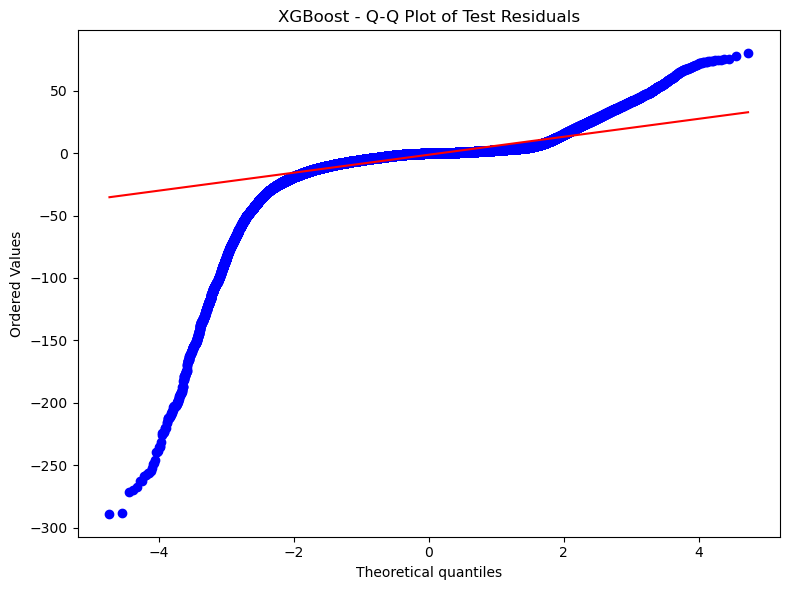

In [25]:
# === 4. Q-Q Plot of Residuals ===
fig, ax = plt.subplots(figsize=(8, 6))
stats.probplot(res_te, dist='norm', plot=ax)
ax.set_title('XGBoost - Q-Q Plot of Test Residuals')
plt.tight_layout()
plt.show()

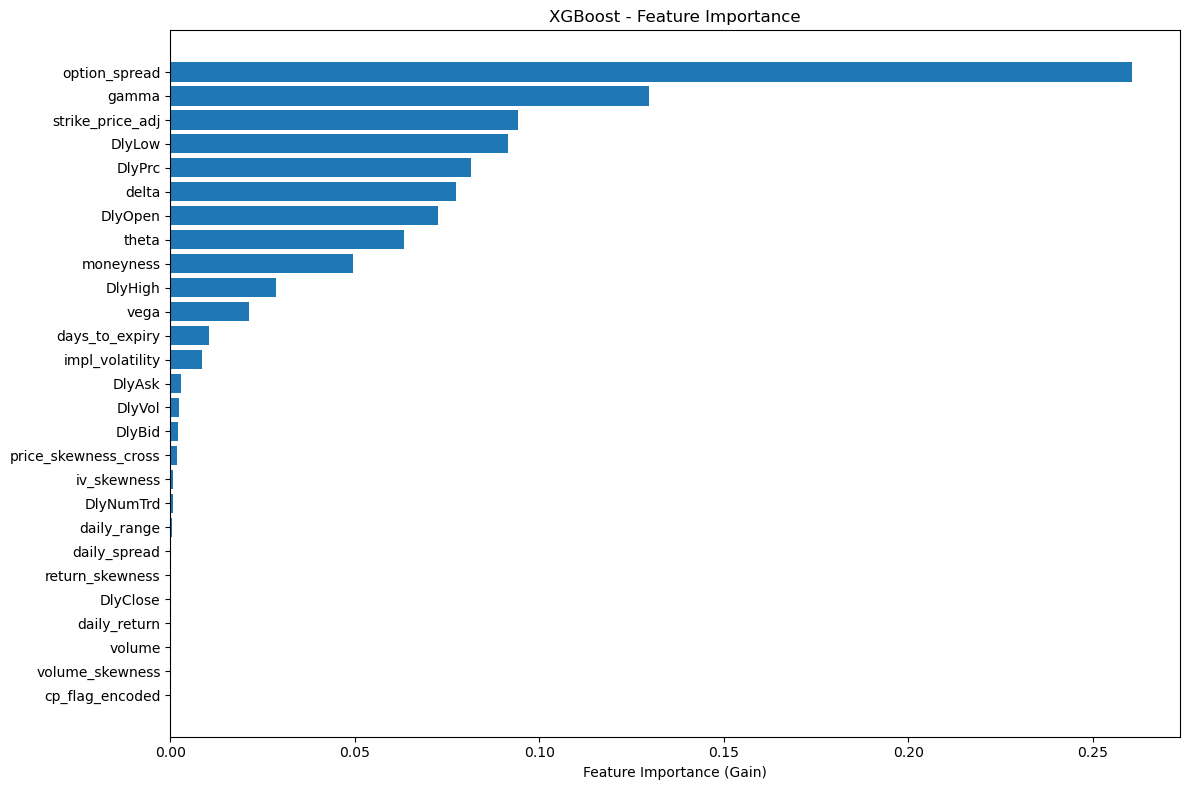

In [26]:
# === 5. Feature Importance (XGBoost built-in) ===
imp_df = pd.DataFrame({
    'Feature': num_features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(imp_df['Feature'], imp_df['Importance'])
plt.xlabel('Feature Importance (Gain)')
plt.title('XGBoost - Feature Importance')
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

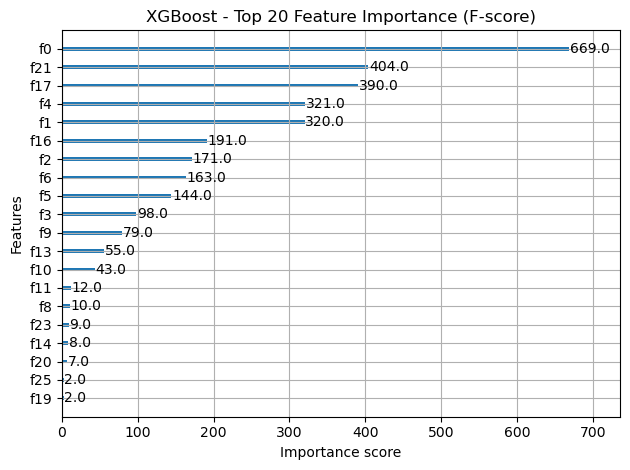

In [27]:
# === 5b. XGBoost built-in importance plot ===
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, max_num_features=20)
plt.title('XGBoost - Top 20 Feature Importance (F-score)')
plt.tight_layout()
plt.show()

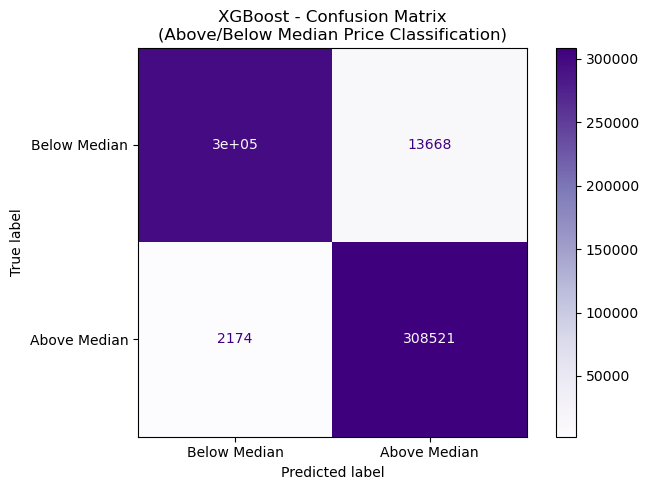


Classification Report (Above/Below Median):
              precision    recall  f1-score   support

Below Median       0.99      0.96      0.97    310673
Above Median       0.96      0.99      0.97    310695

    accuracy                           0.97    621368
   macro avg       0.98      0.97      0.97    621368
weighted avg       0.98      0.97      0.97    621368



In [28]:
# === 6. Confusion Matrix (Above/Below Median Price Classification) ===
median_price = y_test.median()
y_test_class = (y_test.values >= median_price).astype(int)
y_pred_class = (y_pred_te >= median_price).astype(int)

cm = confusion_matrix(y_test_class, y_pred_class)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Below Median', 'Above Median']).plot(ax=ax, cmap='Purples')
ax.set_title('XGBoost - Confusion Matrix\n(Above/Below Median Price Classification)')
plt.tight_layout()
plt.show()

print('\nClassification Report (Above/Below Median):')
print(classification_report(y_test_class, y_pred_class, target_names=['Below Median', 'Above Median']))

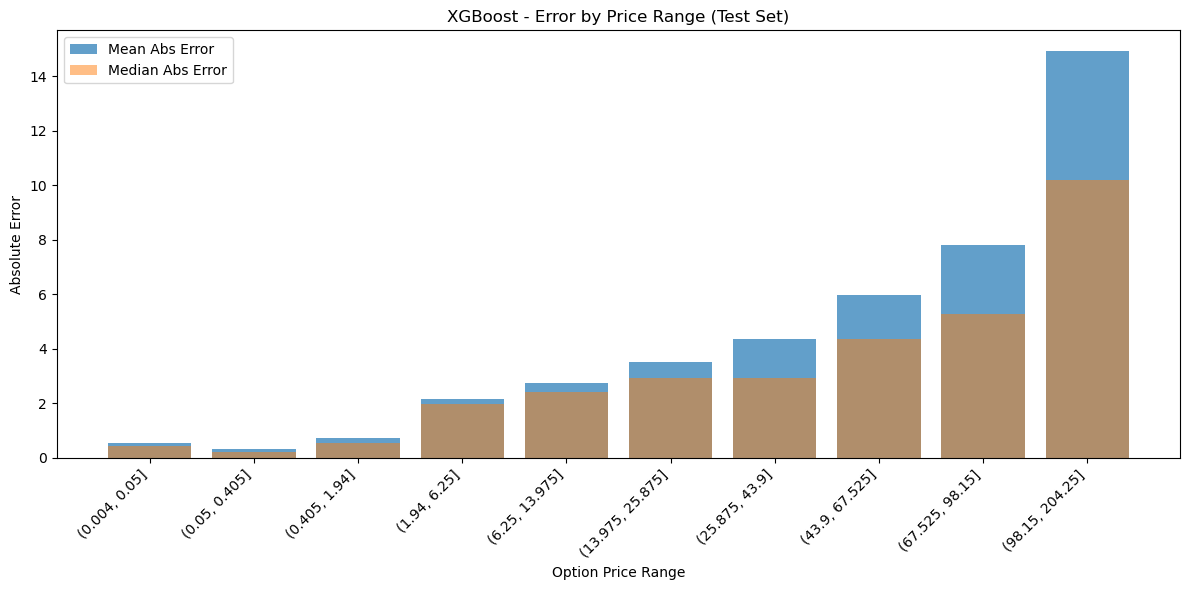

In [29]:
# === 7. Error Distribution by Price Bins ===
test_results = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred_te,
    'residual': res_te,
    'abs_error': np.abs(res_te)
})
test_results['price_bin'] = pd.qcut(test_results['actual'], q=10, duplicates='drop')

bin_errors = test_results.groupby('price_bin')['abs_error'].agg(['mean', 'median']).reset_index()

plt.figure(figsize=(12, 6))
x = range(len(bin_errors))
plt.bar(x, bin_errors['mean'], alpha=0.7, label='Mean Abs Error')
plt.bar(x, bin_errors['median'], alpha=0.5, label='Median Abs Error')
plt.xticks(x, [str(b) for b in bin_errors['price_bin']], rotation=45, ha='right')
plt.xlabel('Option Price Range')
plt.ylabel('Absolute Error')
plt.title('XGBoost - Error by Price Range (Test Set)')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Summary

In [30]:
summary = pd.DataFrame({
    'Set': ['Train', 'Test'],
    'MSE': [tr_m['MSE'], te_m['MSE']],
    'RMSE': [tr_m['RMSE'], te_m['RMSE']],
    'MAE': [tr_m['MAE'], te_m['MAE']],
    'MAPE (%)': [tr_m['MAPE'], te_m['MAPE']],
    'R2': [tr_m['R2'], te_m['R2']],
    'Explained Var': [tr_m['EVS'], te_m['EVS']]
})
print('\n' + '='*70)
print('XGBOOST - SUMMARY')
print('='*70)
print(summary.to_string(index=False))


XGBOOST - SUMMARY
  Set        MSE      RMSE      MAE   MAPE (%)       R2  Explained Var
Train 189.875484 13.779531 7.332134 272.419424 0.995847       0.995847
 Test  84.858012  9.211841 4.308636 699.741965 0.949852       0.950796
